In [1]:
import pandas, numpy, seaborn, random

In [2]:
import scipy, scipy.stats

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# Generate the expression

We are going to generate a random expression matrix with a certain structure, to visualize a nice pattern.  
In a real-case scenario you will be probably reading a tsv or excel file with pandas

In [4]:
number_of_genes = 20
numpy.random.seed(512)
x = numpy.random.random((number_of_genes, 9))
my_columns = ['condA_rep1', 'condA_rep2', 'condA_rep3', 'condB_rep1', 'condB_rep2', 'condB_rep3', 'condC_rep1', 'condC_rep2', 'condC_rep3']
my_index = ['ENS{:03d}'.format(i) for i in range(number_of_genes)]
random.shuffle(my_index)
df = pandas.DataFrame(data=x, index=my_index, columns=my_columns)

df.iloc[:5, :3] = df.iloc[:5, :3]+10
df.iloc[5:10, 3:6] = df.iloc[5:10, 3:6]*100
df.iloc[10:15, 6:9] = df.iloc[10:15, 6:9]*1000

df.sort_index(ascending=True, inplace=True)

It is not necessary that you understand how this test data is generated. But let's have a look to it!

In [5]:
df

,condA_rep1,condA_rep2,condA_rep3,condB_rep1,condB_rep2,condB_rep3,condC_rep1,condC_rep2,condC_rep3
ENS000,10.401963,10.318341,10.419603,0.127848,0.320888,0.158819,0.914869,0.240554,0.800907
ENS001,0.881655,0.232620,0.740352,0.222589,0.958938,0.802988,0.671276,0.872996,0.720255
ENS002,0.667948,0.914006,0.159719,0.900828,0.827319,0.799820,976.627002,762.335565,984.540836
ENS003,0.965106,0.442555,0.383113,26.711619,14.376672,82.826756,0.450355,0.003833,0.947307
ENS004,0.706568,0.258055,0.011802,0.870612,0.710948,0.814187,950.834093,912.893630,87.341991
ENS005,0.570615,0.163580,0.192869,29.901903,22.517788,22.594885,0.794317,0.534955,0.869193
ENS006,10.782196,10.617860,10.901722,0.803453,0.027489,0.670723,0.441884,0.961069,0.336554
ENS007,0.403734,0.825820,0.828071,94.482060,84.901267,60.034704,0.501914,0.449563,0.900484
ENS008,0.258766,0.647559,0.936969,0.844865,0.716453,0.647932,377.212189,338.210139,383.616119
ENS009,0.586619,0.912780,0.992898,0.335173,0.601817,0.780164,332.440543,920.304110,996.440824


# Let's cluster the expression!

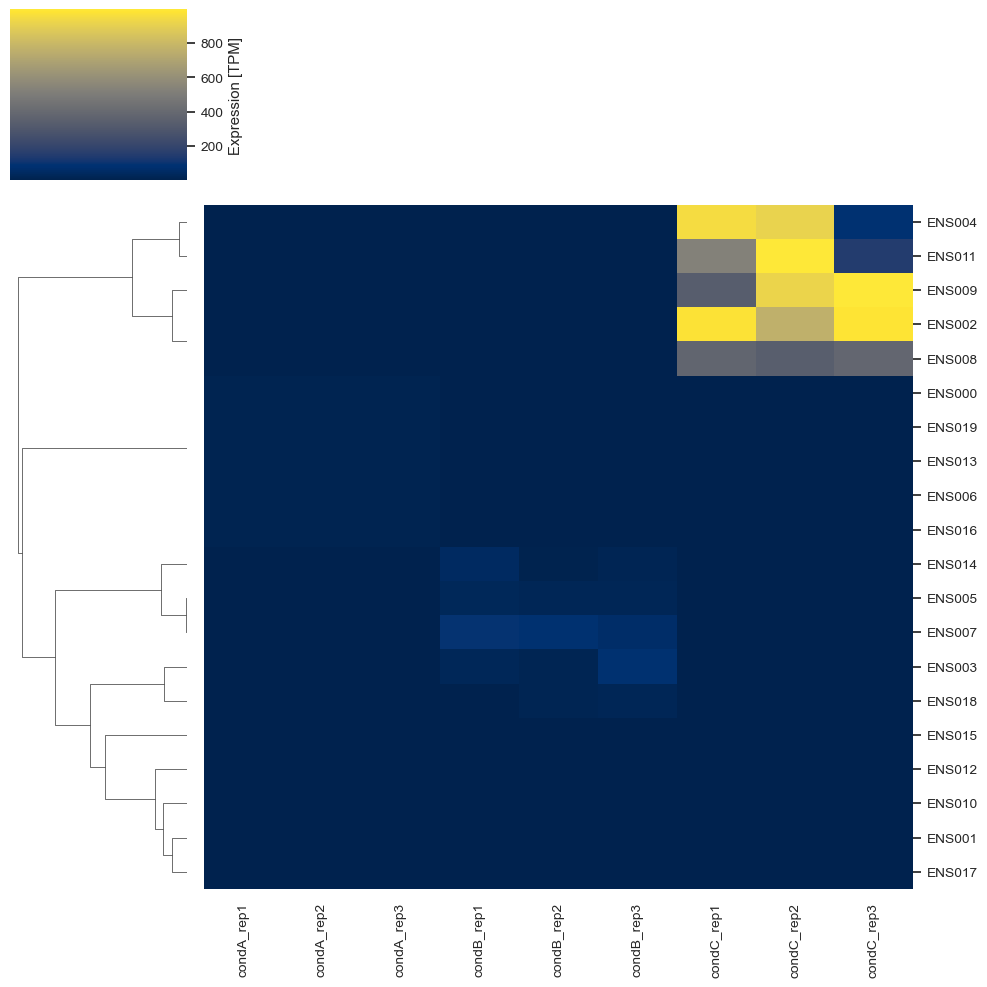

In [6]:
linkage_method = 'complete'
distance_metric = 'cosine'

seaborn.set(font_scale=0.9)
seaborn.clustermap(df, 
                   cmap='cividis',         # why? this is important, check https://matplotlib.org/stable/users/explain/colors/colormaps.html
                   col_cluster=False,      # would you cluster the colums too?
                   method=linkage_method, 
                   metric=distance_metric, 
                   yticklabels=1, 
                   cbar_kws={'label':'Expression [TPM]'})
matplotlib.pyplot.tight_layout()

# Let's think...

Is there anything we could to to improve the heatmap?

In [7]:
zdf = scipy.stats.zscore(df, axis=1) # do you think axis=1 is important, why?
zdf

,condA_rep1,condA_rep2,condA_rep3,condB_rep1,condB_rep2,condB_rep3,condC_rep1,condC_rep2,condC_rep3
ENS000,1.416789,1.398993,1.420544,-0.769788,-0.728704,-0.763196,-0.602291,-0.745801,-0.626545
ENS001,0.797715,-1.746864,0.243725,-1.786190,1.100707,0.489296,-0.027090,0.763766,0.164934
ENS002,-0.700477,-0.699907,-0.701654,-0.699937,-0.700107,-0.700171,1.560092,1.063739,1.578422
ENS003,-0.510127,-0.530386,-0.532691,0.488054,0.009833,2.663614,-0.530084,-0.547396,-0.510817
ENS004,-0.565054,-0.566225,-0.566868,-0.564626,-0.565043,-0.564773,1.915262,1.816218,-0.338891
ENS005,-0.692367,-0.727110,-0.724610,1.811205,1.180933,1.187514,-0.673273,-0.695411,-0.666882
ENS006,1.415222,1.381186,1.439978,-0.651539,-0.812254,-0.679030,-0.726426,-0.618894,-0.748242
ENS007,-0.696390,-0.685354,-0.685295,1.763568,1.513049,0.862839,-0.693823,-0.695192,-0.683401
ENS008,-0.707927,-0.705676,-0.704001,-0.704534,-0.705277,-0.705674,1.473924,1.248175,1.510990
ENS009,-0.636485,-0.635654,-0.635450,-0.637126,-0.636446,-0.635992,0.209104,1.707024,1.901026


In [8]:
### what am I doing here?
print(numpy.sum(zdf.iloc[1, :]))
print(numpy.std(zdf.iloc[1, :]))

-2.7755575615628914e-17
1.0000000000000002


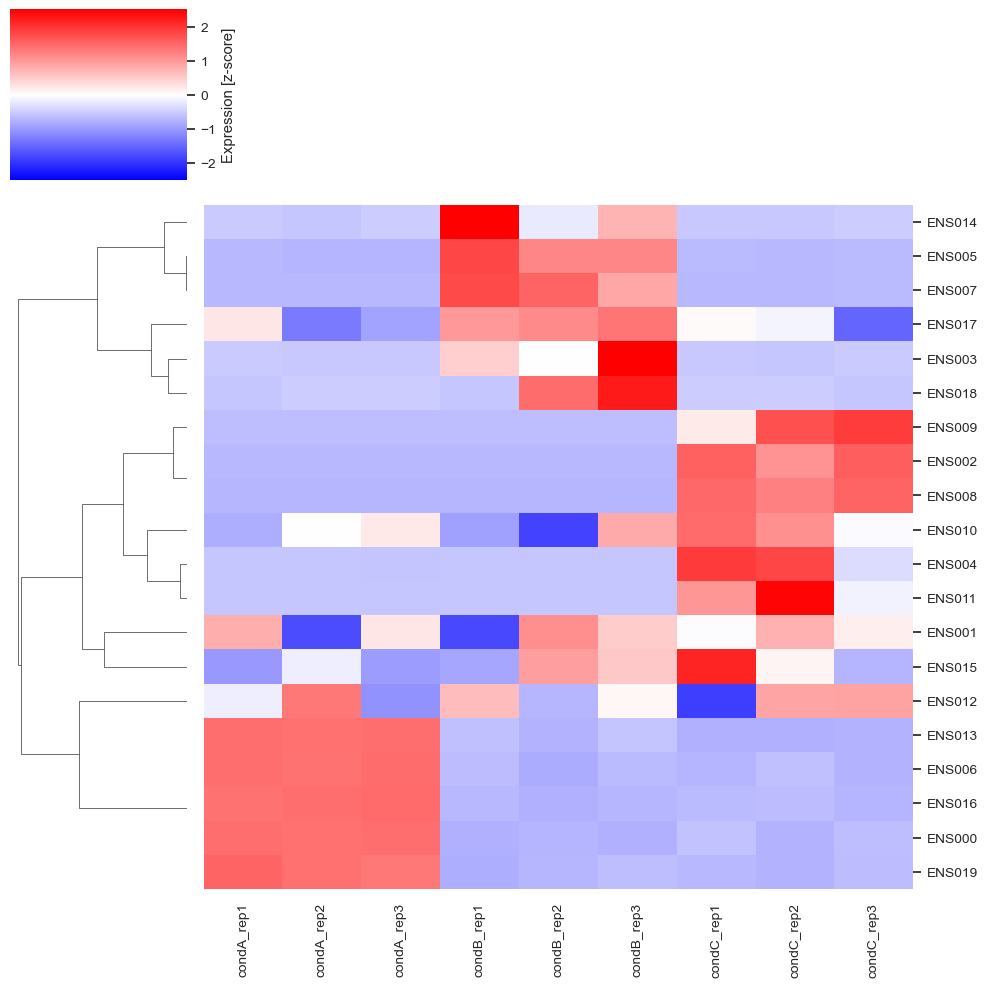

In [9]:
linkage_method = 'complete'
distance_metric = 'cosine'

seaborn.set(font_scale=0.9)
seaborn.clustermap(zdf, 
                   cmap='bwr',       # why now a different color scale?  
                   col_cluster=False, 
                   vmin=-2.5, vmax=2.5,   # why this is important? how did I selected these values? 
                   method=linkage_method, 
                   metric=distance_metric, 
                   yticklabels=1, 
                   cbar_kws={'label':'Expression [z-score]'})
matplotlib.pyplot.tight_layout()

# Let's think (again, sorry)

Is there anything we could to to improve the heatmap?

In [10]:
no_noise = df[df.max(axis=1) > 2] # what am I doing here?

In [11]:
zdf = scipy.stats.zscore(no_noise, axis=1)

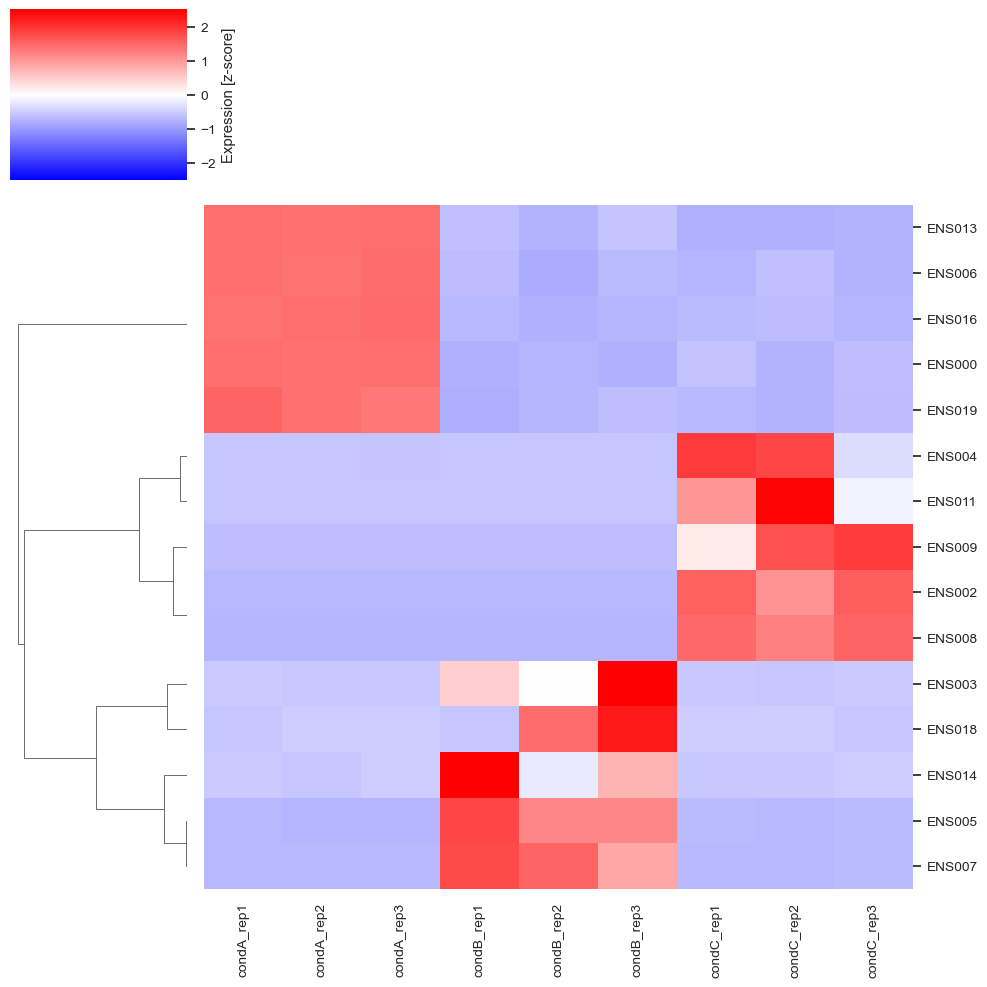

In [12]:
linkage_method = 'complete'
distance_metric = 'cosine'

seaborn.set(font_scale=0.9)
seaborn.clustermap(zdf, 
                   cmap='bwr',       
                   col_cluster=False, 
                   vmin=-2.5, vmax=2.5,   
                   method=linkage_method, 
                   metric=distance_metric, 
                   yticklabels=1, 
                   cbar_kws={'label':'Expression [z-score]'})
matplotlib.pyplot.tight_layout()

Take home message: finding patterns is fun and sometimes tricky. But hey, now you know how to build heatmaps. Stay critical.